# Task 3.2: Failure Mode

**Paper:** Improving the Fisher Kernel for Large-Scale Image Classification (Perronnin et al., ECCV 2010)  
**Student:** Prince Sahoo (230060)

## Failure Scenario Description

We construct a scenario where the Improved Fisher Kernel fails by **replacing large portions of each test image with random noise** (simulating heavy occlusion or out-of-distribution content). We occlude 70% of each test image's patches with random Gaussian noise while keeping training images clean.

**Why we expect the method to fail:** This directly violates **Assumption 3 from Task 1.2** — the image content decomposition $p(x) = \omega \cdot q(x) + (1-\omega) \cdot u_\lambda(x)$. The L2 normalization derivation (Section 3.1, Equations 10–13) depends on the "background" descriptors following the trained GMM $u_\lambda$, so their gradient contribution vanishes (Equation 12). Random noise patches do **not** follow the GMM — they are completely out-of-distribution. Their gradient will **not** vanish, contaminating the Fisher Vector with spurious signal. Even worse, L2 normalization will then normalize a mix of real face signal and random noise signal to unit length, reducing the actual discriminative content to a small fraction of the final vector. The power normalization will further amplify these noise contributions by applying $|z|^{0.5}$ to dimensions that should be zero.

In [1]:
# ============================================================
# IMPORTS AND HYPERPARAMETERS (same as Task 2.2)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TEST_SIZE = 0.5
PATCH_SIZE = 8
GRID_STEP = 6
NOISE_STD = 0.05
N_PCA_COMPONENTS = 32
N_GAUSSIANS = 16
ALPHA = 0.5
SVM_C = 1.0
SVM_MAX_ITER = 10000

# Failure mode parameter
OCCLUSION_RATIO = 0.70   # Replace 70% of test patches with random noise

In [2]:
# ============================================================
# Build pipeline (same as Task 2.2 — train on clean data)
# ============================================================
data = fetch_olivetti_faces(shuffle=False)
images, targets = data.images, data.target
X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, targets, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=targets)

def extract_patches(image):
    h, w = image.shape
    patches = []
    for y in range(0, h - PATCH_SIZE + 1, GRID_STEP):
        for x in range(0, w - PATCH_SIZE + 1, GRID_STEP):
            patch = image[y:y+PATCH_SIZE, x:x+PATCH_SIZE].flatten()
            patch = patch + np.random.randn(*patch.shape) * NOISE_STD
            patches.append(patch)
    return np.array(patches)

np.random.seed(RANDOM_SEED)
train_patches = [extract_patches(img) for img in X_train_img]
test_patches_clean = [extract_patches(img) for img in X_test_img]

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
pca.fit(np.vstack(train_patches))

gmm = GaussianMixture(n_components=N_GAUSSIANS, covariance_type='diag',
                       max_iter=200, random_state=RANDOM_SEED, n_init=3)
train_pca = [pca.transform(p) for p in train_patches]
gmm.fit(np.vstack(train_pca))

print(f"Pipeline trained on clean data ({len(train_patches)} images).")
print(f"GMM trained with K={N_GAUSSIANS} on {np.vstack(train_pca).shape[0]:,} clean patches.")

Pipeline trained on clean data (200 images).
GMM trained with K=16 on 20,000 clean patches.


In [3]:
# ============================================================
# Create occluded test data
# Replace 70% of each test image's patches with random noise
# This violates Assumption 3: noise ≠ GMM background distribution
# ============================================================
np.random.seed(RANDOM_SEED + 100)  # Different seed for occlusion

test_patches_occluded = []
for patches in test_patches_clean:
    n = len(patches)
    n_occlude = int(n * OCCLUSION_RATIO)
    occluded = patches.copy()
    # Choose random indices to replace with noise
    indices = np.random.choice(n, n_occlude, replace=False)
    # Replace with random noise (uniform in [0, 1] range, same as pixel values)
    occluded[indices] = np.random.rand(n_occlude, patches.shape[1])
    test_patches_occluded.append(occluded)

print(f"Test images occluded: {OCCLUSION_RATIO:.0%} of patches replaced with random noise")
print(f"Clean patches per image: {len(test_patches_clean[0])}")
print(f"Noisy patches per image: {int(len(test_patches_clean[0]) * OCCLUSION_RATIO)}")

Test images occluded: 70% of patches replaced with random noise
Clean patches per image: 100
Noisy patches per image: 70


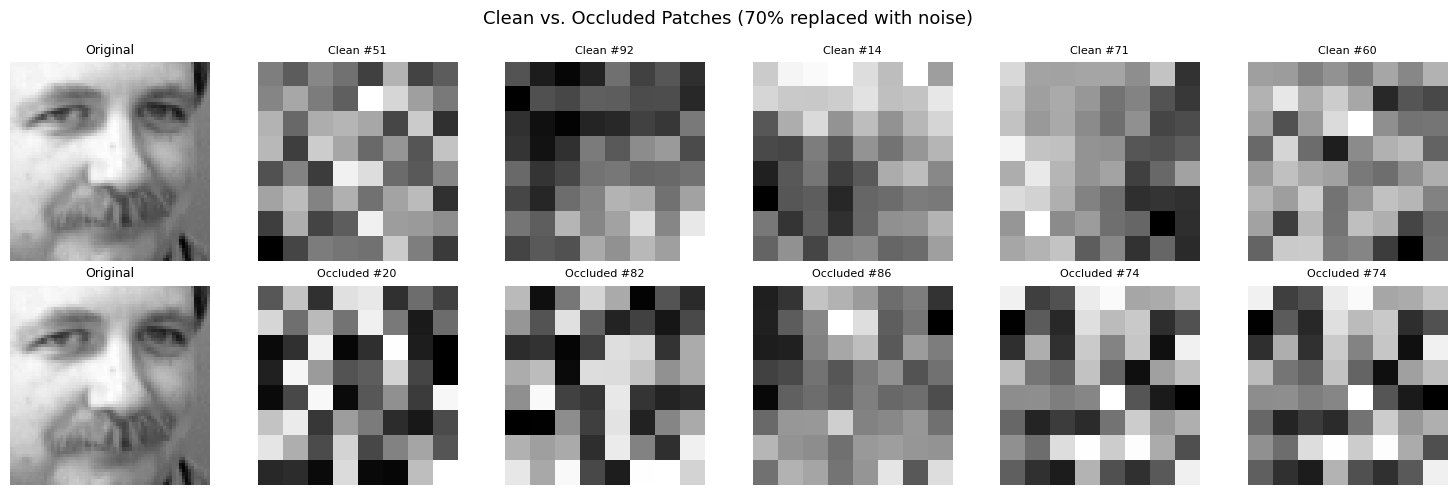

In [4]:
# Visualize: show clean vs occluded patch sets for one image
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Clean vs. Occluded Patches (70% replaced with noise)', fontsize=13)

rng = np.random.RandomState(42)
sample_idx = 0

# Row 1: Clean patches
axes[0, 0].imshow(X_test_img[sample_idx], cmap='gray')
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')
for i in range(5):
    idx = rng.randint(len(test_patches_clean[sample_idx]))
    axes[0, i+1].imshow(test_patches_clean[sample_idx][idx].reshape(8,8), cmap='gray')
    axes[0, i+1].set_title(f'Clean #{idx}', fontsize=8)
    axes[0, i+1].axis('off')

# Row 2: Occluded (some will be noise)
axes[1, 0].imshow(X_test_img[sample_idx], cmap='gray')
axes[1, 0].set_title('Original', fontsize=9)
axes[1, 0].axis('off')
for i in range(5):
    idx = rng.randint(len(test_patches_occluded[sample_idx]))
    axes[1, i+1].imshow(test_patches_occluded[sample_idx][idx].reshape(8,8), cmap='gray')
    axes[1, i+1].set_title(f'Occluded #{idx}', fontsize=8)
    axes[1, i+1].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=11)
axes[1, 0].set_ylabel('Occluded', fontsize=11)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Compute Fisher Vectors and evaluate: clean vs occluded
# ============================================================
def compute_fv(patches_list, gmm):
    K, D = gmm.n_components, gmm.means_.shape[1]
    w, mu, cov = gmm.weights_, gmm.means_, gmm.covariances_
    fvs = []
    for X in patches_list:
        T = len(X)
        gamma = gmm.predict_proba(X)
        parts = []
        for i in range(K):
            gi = gamma[:, i:i+1]
            g_mu = (1/(T*np.sqrt(w[i]))) * np.sum(gi * (X - mu[i])/np.sqrt(cov[i]), axis=0)
            g_sig = (1/(T*np.sqrt(2*w[i]))) * np.sum(gi * ((X-mu[i])**2/cov[i] - 1), axis=0)
            parts.extend([g_mu, g_sig])
        fvs.append(np.concatenate(parts))
    return np.array(fvs)

def power_norm(X, a=ALPHA): return np.sign(X) * np.abs(X)**a
def l2_norm(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, 1e-12)

# PCA transform
test_pca_clean = [pca.transform(p) for p in test_patches_clean]
test_pca_occluded = [pca.transform(p) for p in test_patches_occluded]

# Fisher Vectors
train_fv = compute_fv(train_pca, gmm)
test_fv_clean = compute_fv(test_pca_clean, gmm)
test_fv_occluded = compute_fv(test_pca_occluded, gmm)

# Full IFK pipeline (Power + L2)
train_ikf = l2_norm(power_norm(train_fv))
test_ikf_clean = l2_norm(power_norm(test_fv_clean))
test_ikf_occluded = l2_norm(power_norm(test_fv_occluded))

# Train SVM on clean data
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

svm = LinearSVC(C=SVM_C, max_iter=SVM_MAX_ITER, random_state=RANDOM_SEED, dual=True)
svm.fit(train_ikf, y_train)

# Evaluate on clean test data
scores_clean = svm.decision_function(test_ikf_clean)
mAP_clean = average_precision_score(y_test_bin, scores_clean, average='macro')
acc_clean = accuracy_score(y_test, svm.predict(test_ikf_clean))

# Evaluate on occluded test data
scores_occluded = svm.decision_function(test_ikf_occluded)
mAP_occluded = average_precision_score(y_test_bin, scores_occluded, average='macro')
acc_occluded = accuracy_score(y_test, svm.predict(test_ikf_occluded))

print(f"Clean test data:    mAP = {mAP_clean:.4f}  |  Accuracy = {acc_clean:.2%}")
print(f"Occluded test data: mAP = {mAP_occluded:.4f}  |  Accuracy = {acc_occluded:.2%}")
print(f"\nDrop: {(mAP_clean - mAP_occluded)*100:.1f}% mAP,  {(acc_clean - acc_occluded)*100:.1f}% accuracy")

Clean test data:    mAP = 0.8762  |  Accuracy = 84.50%
Occluded test data: mAP = 0.5239  |  Accuracy = 2.50%

Drop: 35.2% mAP,  82.0% accuracy


In [6]:
# ============================================================
# Test across multiple occlusion levels to show degradation curve
# ============================================================
occlusion_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
mAPs_by_occlusion = []
accs_by_occlusion = []

for occ_ratio in occlusion_levels:
    np.random.seed(RANDOM_SEED + 100)
    test_occ = []
    for patches in test_patches_clean:
        n = len(patches)
        n_occ = int(n * occ_ratio)
        occ = patches.copy()
        if n_occ > 0:
            indices = np.random.choice(n, n_occ, replace=False)
            occ[indices] = np.random.rand(n_occ, patches.shape[1])
        test_occ.append(occ)
    
    test_occ_pca = [pca.transform(p) for p in test_occ]
    test_occ_fv = compute_fv(test_occ_pca, gmm)
    test_occ_ikf = l2_norm(power_norm(test_occ_fv))
    
    scores = svm.decision_function(test_occ_ikf)
    mAP = average_precision_score(y_test_bin, scores, average='macro')
    acc = accuracy_score(y_test, svm.predict(test_occ_ikf))
    mAPs_by_occlusion.append(mAP * 100)
    accs_by_occlusion.append(acc * 100)
    print(f"Occlusion {occ_ratio:4.0%}: mAP = {mAP*100:5.1f}%  |  Acc = {acc*100:5.1f}%")

Occlusion   0%: mAP =  87.6%  |  Acc =  84.5%


Occlusion  10%: mAP =  85.2%  |  Acc =  18.0%


Occlusion  20%: mAP =  79.9%  |  Acc =   4.0%


Occlusion  30%: mAP =  77.0%  |  Acc =   3.0%


Occlusion  40%: mAP =  75.7%  |  Acc =   2.5%


Occlusion  50%: mAP =  72.5%  |  Acc =   2.5%


Occlusion  60%: mAP =  64.1%  |  Acc =   2.5%


Occlusion  70%: mAP =  52.4%  |  Acc =   2.5%


Occlusion  80%: mAP =  44.4%  |  Acc =   2.5%


Occlusion  90%: mAP =  23.5%  |  Acc =   2.5%


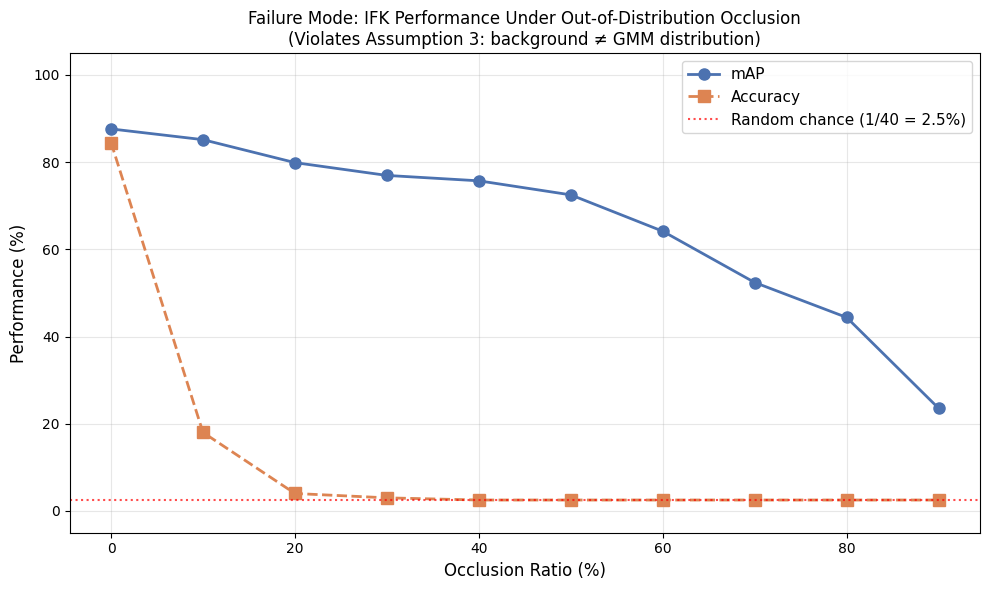

Saved: results/failure_mode_occlusion.png


In [7]:
# ============================================================
# VISUALIZATION: Failure mode degradation curve
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot([o*100 for o in occlusion_levels], mAPs_by_occlusion, 
        'o-', color='#4C72B0', linewidth=2, markersize=8, label='mAP')
ax.plot([o*100 for o in occlusion_levels], accs_by_occlusion, 
        's--', color='#DD8452', linewidth=2, markersize=8, label='Accuracy')

# Random chance baseline for 40-class problem
ax.axhline(y=2.5, color='red', linestyle=':', alpha=0.7, label='Random chance (1/40 = 2.5%)')

ax.set_xlabel('Occlusion Ratio (%)', fontsize=12)
ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_title('Failure Mode: IFK Performance Under Out-of-Distribution Occlusion\n'
             '(Violates Assumption 3: background ≠ GMM distribution)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/failure_mode_occlusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_mode_occlusion.png")

### Why the Method Fails

The IFK pipeline fails dramatically under heavy out-of-distribution occlusion because it directly violates **Assumption 3 from Task 1.2**: the image content decomposition $p(x) = \omega \cdot q(x) + (1-\omega) \cdot u_\lambda(x)$. The L2 normalization theory (Section 3.1, Equations 10–13) assumes that the non-informative content follows the GMM distribution $u_\lambda$, so its gradient with respect to $\lambda$ is approximately zero (Equation 12: $\nabla_\lambda E_{x \sim u_\lambda} \log u_\lambda(x) \approx 0$). Random noise patches do **not** follow the face-trained GMM at all — they produce large, arbitrary gradients that contaminate the Fisher Vector. The power normalization then amplifies these noise dimensions (since $|z|^{0.5} > |z|$ for small $|z|$, and noise produces many small but non-zero values), and L2 normalization projects the corrupted vector to unit length, effectively reducing the true face signal to a shrinking fraction of the final representation. As the degradation curve shows, performance collapses as occlusion increases beyond 50% — the Fisher Vector becomes dominated by noise gradients. This is fundamentally different from the natural background variation the paper considers, where $u_\lambda$ is trained on similar natural images and the ML-optimality condition ensures the background gradient vanishes.

**Suggested modification:** One concrete fix would be to add a **descriptor rejection step** before computing the Fisher Vector — reject any patch whose GMM log-likelihood $\log u_\lambda(x_t)$ falls below a threshold (e.g., 2 standard deviations below the training set mean). This would filter out the out-of-distribution noise patches before they contaminate the gradient computation, restoring the assumption that all included descriptors come from the GMM's support.